# Reproducing Hogg, Eilers & Rix (2018) on the original DR14 dataset

Verifies our code against Paper I using the **original** data, assembled by `assemble_hogg18.py`:

| file | contents | needed for |
|---|---|---|
| `hogg2018.fits` (repo root) | the paper's released catalog (Zenodo 1468053): 44784 stars, their `spec_parallax`, `training_set` flag, A/B split | everything below |
| `data/hogg18/hogg18_meta.parquet` | rebuilt inputs: Gaia DR2 G/BP/RP + parallax + astrometric quality, 2MASS J/H/K, WISE W1/W2, APOGEE Teff/logg/[Fe/H]/SNR | sections 1–6 |
| `data/hogg18/hogg18_spectra.parquet` | 44784 normalized aspcapStar spectra (Eilers' procedure) | section 7 only |

**Do we need the spectra?** Sections 1–6 reproduce the paper's sample cuts, figures and the headline "<9%" number from the *published predictions* — no spectra required. Only section 7 (retraining the model with our own pipeline and comparing star-by-star) needs the ~10 GB spectra download.

Paper: [arXiv:1810.09468](https://arxiv.org/abs/1810.09468). Their model: $\varpi^{(sp)} = \exp(\theta\cdot x)$, features $x = [1, G, G_{BP}, G_{RP}, J, H, K, W_1, W_2, \ln f_1 \ldots \ln f_{7405}]$, trained on Gaia DR2 parallaxes adjusted by $\varpi_0 = +0.048$ mas, with **no** parallax or parallax-S/N cuts.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spphot.eval import robust_scatter, fractional_residuals, hi_snr_mask, evaluate, chi2_stats

M = pd.read_parquet('../data/hogg18/hogg18_meta.parquet')
HOGG_OFFSET = 0.048   # mas, added to Gaia parallaxes in Paper I (their sec. 4)
print(f'{len(M)} stars, {M.columns.size} columns')
M.head(3)

44784 stars, 36 columns


,sdss_id,hogg_gaia_parallax,hogg_gaia_parallax_err,spec_parallax,spec_parallax_err,hogg_training_set,hogg_sample,ra,dec,j_mag,...,e_plx,visibility_periods_used,astrometric_chi2_al,astrometric_n_good_obs_al,phot_variable_flag,w1_mag,w2_mag,zeropoint,spectrum_flags,r_med_photogeo
0,2M00000002+7417074,0.3191,0.0329,0.3185,0.0164,0,B,0.000103,74.285408,8.597,...,0.032948,18,1236.840698,270,NOT_AVAILABLE,7.257,7.353,-0.048,0,NaN
1,2M00000317+5821383,0.3643,0.0510,0.4428,0.0183,0,A,0.013232,58.360649,8.206,...,0.050991,18,1424.723877,287,NOT_AVAILABLE,6.804,6.951,-0.048,0,NaN
2,2M00000546+6152107,0.3154,0.0351,0.3292,0.0164,0,B,0.022759,61.869644,9.013,...,0.035141,17,747.635254,305,NOT_AVAILABLE,7.523,7.682,-0.048,0,NaN


## 1. Sample definition (paper §4, eqs. 6–10)

Checks that our rebuilt metadata reproduces the paper's sample arithmetic: 44784 Parent Sample stars, 28226 Training Set stars, the two color cuts, the log g range, and the three astrometric-quality cuts. Also checks our freshly-queried Gaia DR2 parallaxes against the values frozen in the paper's catalog.

In [2]:
print(f'Parent Sample:               {len(M):6d}   (paper: 44784)')
print(f'training_set flag:           {int(M.hogg_training_set.sum()):6d}   (paper: 28226)')
print(f"A / B split:                 {int((M.hogg_sample=='A').sum())} / {int((M.hogg_sample=='B').sum())}")

jk, bprp, hw2 = M.j_mag - M.k_mag, M.bp_mag - M.rp_mag, M.h_mag - M.w2_mag
print(f'eq. 6  (J-K)  < 0.4+0.45(BP-RP): {int((jk < 0.4 + 0.45*bprp).sum()):6d} pass')
print(f'eq. 7  (H-W2) > -0.05:           {int((hw2 > -0.05).sum()):6d} pass')
print(f'0 < logg <= 2.2:                 {int(((M.logg > 0) & (M.logg <= 2.2)).sum()):6d}')

# eqs. 8-10: parallax_error < 0.1  &  visibility_periods_used >= 8  &  chi2 criterion
tr = ((M.e_plx < 0.1) & (M.visibility_periods_used >= 8)
      & (M.astrometric_chi2_al / np.sqrt(M.astrometric_n_good_obs_al - 5) <= 35))
agree = int((tr.fillna(False) == (M.hogg_training_set == 1)).sum())
print(f'eqs. 8-10 re-derived:            {int(tr.sum()):6d}   (flag agreement: {agree}/{len(M)})')

# the catalog's Gaia_parallax is the ADJUSTED parallax: our raw DR2 query
# differs by exactly +0.048 mas, star for star — the offset recovered to the digit
dplx = (M.plx + HOGG_OFFSET - M.hogg_gaia_parallax).abs()
print(f'\nGaia parallax (+0.048) vs paper catalog: median |diff| = {np.nanmedian(dplx):.2e} mas, '
      f'99.9%ile = {np.nanquantile(dplx, 0.999):.2e} mas')
print(f'stars missing Gaia parallax (2-param solutions): {int(M.plx.isna().sum())}')
print(f'stars missing WISE:              {int(M.w2_mag.isna().sum())}')

Parent Sample:                44784   (paper: 44784)
training_set flag:            28226   (paper: 28226)
A / B split:                 22349 / 22435
eq. 6  (J-K)  < 0.4+0.45(BP-RP):  44783 pass
eq. 7  (H-W2) > -0.05:            44784 pass
0 < logg <= 2.2:                  43503
eqs. 8-10 re-derived:             28226   (flag agreement: 44784/44784)

Gaia parallax (+0.048) vs paper catalog: median |diff| = 3.00e-04 mas, 99.9%ile = 3.50e-04 mas
stars missing Gaia parallax (2-param solutions): 30
stars missing WISE:              0


## 2. Figure 1 — color–color diagrams

Top row: Parent Sample; bottom row: Training Set. Grey lines are the eq. 6/7 outlier cuts. Colored by APOGEE log g (viridis, as in the paper).

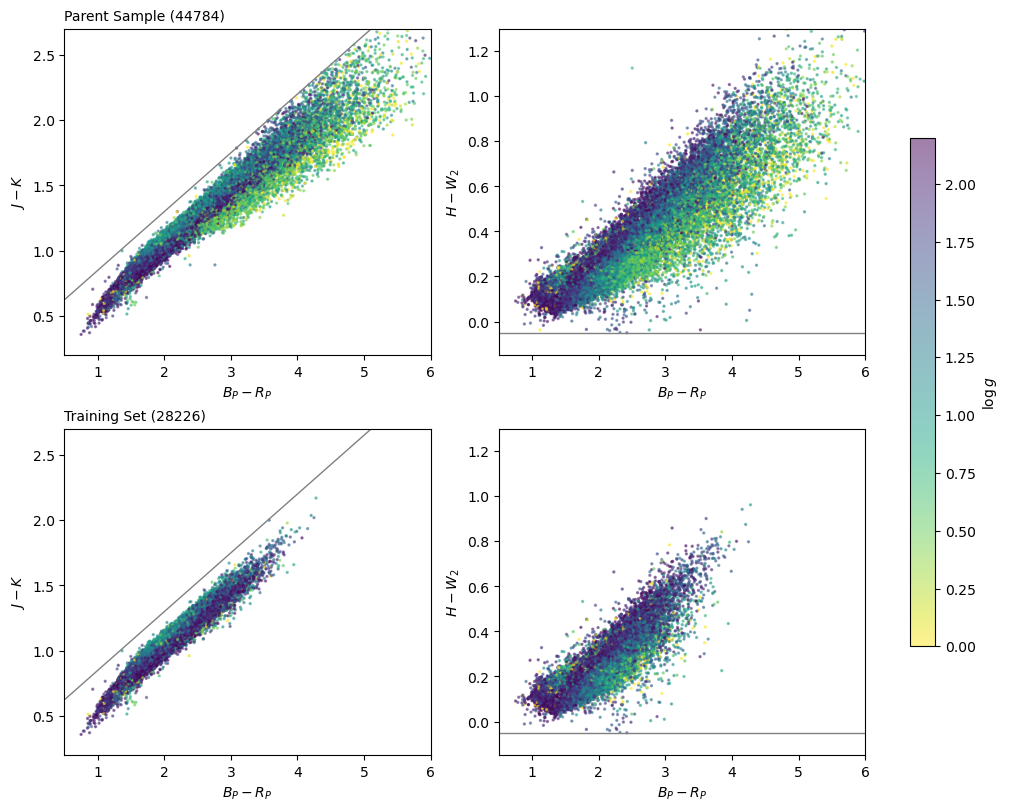

In [3]:
def fig1_panel(ax, d, ycol, ylab, ylim):
    s = ax.scatter(d.bp_mag - d.rp_mag, ycol(d), c=d.logg, s=2, alpha=0.5,
                   cmap='viridis_r', vmin=0, vmax=2.2, rasterized=True)
    ax.set_xlim(0.5, 6); ax.set_ylim(*ylim); ax.set_xlabel('$B_P - R_P$'); ax.set_ylabel(ylab)
    return s

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for row, (d, name) in enumerate([(M, 'Parent Sample'),
                                 (M[M.hogg_training_set == 1], 'Training Set')]):
    s = fig1_panel(axes[row, 0], d, lambda d: d.j_mag - d.k_mag, '$J - K$', (0.2, 2.7))
    xx = np.array([0.5, 6]); axes[row, 0].plot(xx, 0.4 + 0.45*xx, color='0.5', lw=1)
    fig1_panel(axes[row, 1], d, lambda d: d.h_mag - d.w2_mag, '$H - W_2$', (-0.15, 1.3))
    axes[row, 1].axhline(-0.05, color='0.5', lw=1)
    axes[row, 0].set_title(f'{name} ({len(d)})', loc='left', fontsize=10)
fig.colorbar(s, ax=axes, label='$\\log g$', shrink=0.7)
plt.show()

## 3. Figure 2 + the headline number (<9% scatter)

Left: full Training Set, spectrophotometric vs Gaia parallax, colored by APOGEE spectral S/N. Right: the high-S/N probe $\varpi^{(a)}/\sigma_{\varpi^{(a)}} \ge 20$, on which the paper quotes **scatter better than 9 percent**.

We score the paper's published `spec_parallax` through **our own** `spphot.eval` (`robust_scatter` = 1.48·MAD on fractional residuals, same hi-S/N probe) — if our metric code is right, it should land just under 9%. This is the same code path that produced our 9.76% (linear DR17) and 8.26% (het-NN) numbers, so the comparison is apples-to-apples.

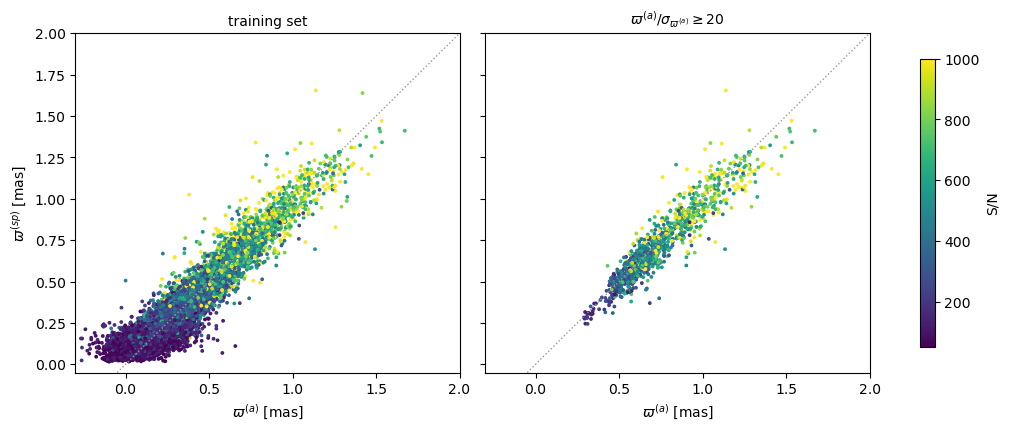

hi-S/N probe:          1068 stars
robust frac scatter:   9.41%   (paper: <9%)
median frac bias:      -2.82%
mean / robust chi2:    2.06 / 1.81   (paper: mean >1, outlier-driven; robust ~consistent)

[reference] ours on DR17: 9.76% linear baseline, 8.26% het-NN


In [4]:
T = M[M.hogg_training_set == 1]
plx_a, err_a = T.plx.to_numpy(), T.e_plx.to_numpy()
plx_sp, err_sp = T.spec_parallax.to_numpy(), T.spec_parallax_err.to_numpy()
probe = hi_snr_mask(plx_a, err_a, 20.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True, constrained_layout=True)
for ax, sel, title in [(axes[0], np.ones(len(T), bool), 'training set'),
                       (axes[1], probe, '$\\varpi^{(a)}/\\sigma_{\\varpi^{(a)}} \\geq 20$')]:
    s = ax.scatter(plx_a[sel] + HOGG_OFFSET, plx_sp[sel], c=T.snr[sel], s=3,
                   cmap='viridis', vmin=50, vmax=1000, rasterized=True)
    ax.plot([-0.3, 2], [-0.3, 2], ':', color='0.6', lw=1)
    ax.set_xlim(-0.3, 2); ax.set_ylim(-0.05, 2)
    ax.set_xlabel('$\\varpi^{(a)}$ [mas]'); ax.set_title(title, fontsize=10)
axes[0].set_ylabel('$\\varpi^{(sp)}$ [mas]')
fig.colorbar(s, ax=axes, label='S/N', shrink=0.85)
plt.show()

cat = dict(plx_a=plx_a, err_a=err_a, plx_sp=plx_sp, err_sp=err_sp,
           sample=T.hogg_sample.to_numpy())
rep = evaluate(cat, snr_thresh=20.0, offset=HOGG_OFFSET, label='Hogg+18 published')
print(f"hi-S/N probe:          {rep['n_hi_snr_probe']} stars")
print(f"robust frac scatter:   {100*rep['robust_frac_scatter']:.2f}%   (paper: <9%)")
print(f"median frac bias:      {100*rep['median_frac_resid']:+.2f}%")
print(f"mean / robust chi2:    {rep['chi2_mean_chi2']:.2f} / {rep['chi2_robust_chi2']:.2f}"
      '   (paper: mean >1, outlier-driven; robust ~consistent)')
print(f"\n[reference] ours on DR17: 9.76% linear baseline, 8.26% het-NN")

## 4. Figure 3 — residuals colored by housekeeping features

Predicted vs Gaia parallax on the hi-S/N probe, colored by $T_{\rm eff}$, $\log g$, [Fe/H] and $H-W_2$ (reddening proxy). The paper finds no trends except larger scatter at red $H-W_2$ (dusty/crowded regions).

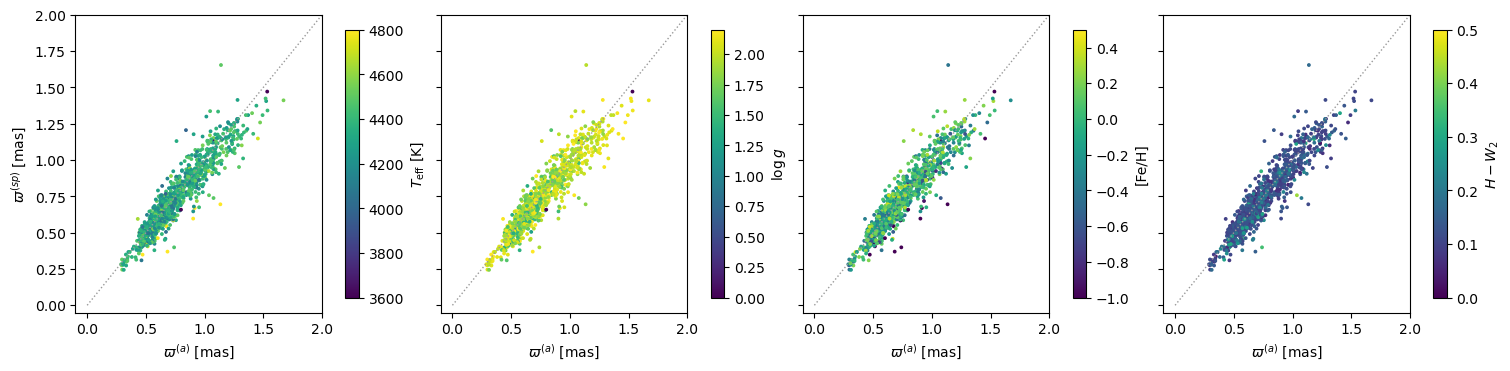

Teff    scatter below/above median: 9.49% / 9.42%
logg    scatter below/above median: 9.41% / 9.60%
[Fe/H]  scatter below/above median: 9.15% / 9.72%


In [5]:
feats = [('teff', '$T_{\\rm eff}$ [K]', (3600, 4800)),
         ('logg', '$\\log g$', (0.0, 2.2)),
         ('fe_h', '[Fe/H]', (-1.0, 0.5)),
         (None, '$H - W_2$', (0.0, 0.5))]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True, constrained_layout=True)
for ax, (col, lab, (v0, v1)) in zip(axes, feats):
    c = (T.h_mag - T.w2_mag)[probe] if col is None else T[col][probe]
    s = ax.scatter(plx_a[probe] + HOGG_OFFSET, plx_sp[probe], c=c, s=3,
                   cmap='viridis', vmin=v0, vmax=v1, rasterized=True)
    ax.plot([0, 2], [0, 2], ':', color='0.6', lw=1)
    ax.set_xlim(-0.1, 2); ax.set_ylim(-0.05, 2); ax.set_xlabel('$\\varpi^{(a)}$ [mas]')
    fig.colorbar(s, ax=ax, label=lab, shrink=0.9)
axes[0].set_ylabel('$\\varpi^{(sp)}$ [mas]')
plt.show()

frac = fractional_residuals(plx_sp[probe], plx_a[probe], HOGG_OFFSET)
for col, lab in [('teff', 'Teff'), ('logg', 'logg'), ('fe_h', '[Fe/H]')]:
    lo, hi = np.nanmedian(T[col][probe]), None
    below = frac[(T[col][probe] <= lo).to_numpy()]
    above = frac[(T[col][probe] > lo).to_numpy()]
    print(f'{lab:7s} scatter below/above median: '
          f'{100*robust_scatter(below):.2f}% / {100*robust_scatter(above):.2f}%')

## 5. Figure 5 — spectrophotometric vs astrometric precision

Spectrophotometric distance vs G magnitude, colored by $\log_{10}(\sigma_{\varpi^{(a)}}/\sigma_{\varpi^{(sp)}})$ (red = our estimate is more precise than Gaia's). Diverging colormap with a neutral midpoint at equal precision.

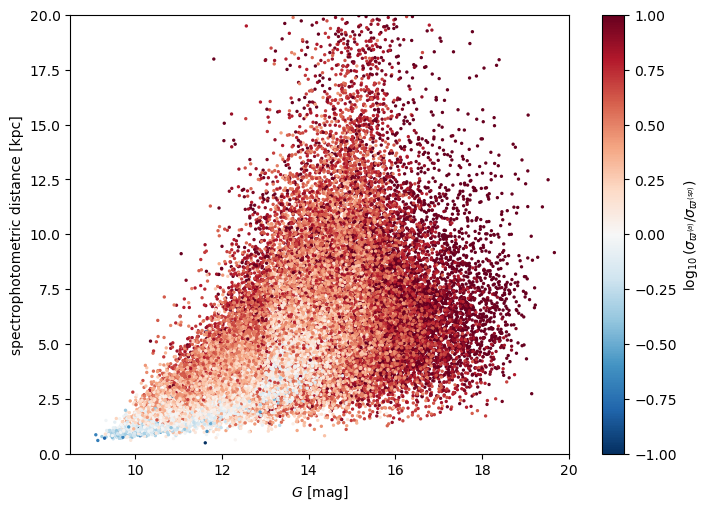

stars where spphot is more precise than Gaia: 93.5%  (paper: 'the vast majority')
median spphot fractional error: 6.8%  (paper: a few to 15 percent)


In [6]:
d_kpc = 1.0 / M.spec_parallax          # mas -> kpc
ratio = np.log10(M.e_plx / M.spec_parallax_err)
sel = np.isfinite(d_kpc) & np.isfinite(ratio) & (d_kpc > 0) & (d_kpc < 20)
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
s = ax.scatter(M.g_mag[sel], d_kpc[sel], c=ratio[sel], s=2, cmap='RdBu_r',
               vmin=-1, vmax=1, rasterized=True)
ax.set_xlim(8.5, 20); ax.set_ylim(0, 20)
ax.set_xlabel('$G$ [mag]'); ax.set_ylabel('spectrophotometric distance [kpc]')
fig.colorbar(s, ax=ax, label='$\\log_{10}(\\sigma_{\\varpi^{(a)}}/\\sigma_{\\varpi^{(sp)}})$')
plt.show()
print(f'stars where spphot is more precise than Gaia: '
      f'{100*np.mean(ratio[sel] > 0):.1f}%  (paper: \'the vast majority\')')
print(f'median spphot fractional error: {100*np.nanmedian(M.spec_parallax_err/M.spec_parallax):.1f}%'
      '  (paper: a few to 15 percent)')

## 6. Figure 4 — cluster sanity check (approximate)

The paper hand-selected members of three clusters using sky position + proper motion; we did not pull proper motions, so this uses a sky-cone + parallax-window selection instead — an *approximate* membership, good enough to see whether $\varpi^{(sp)}$ and $\varpi^{(a)}$ cluster around the same value (and to look for the M71 offset the paper flags as troubling). “NGC2862” in the paper's figure is NGC 2682 = M67.

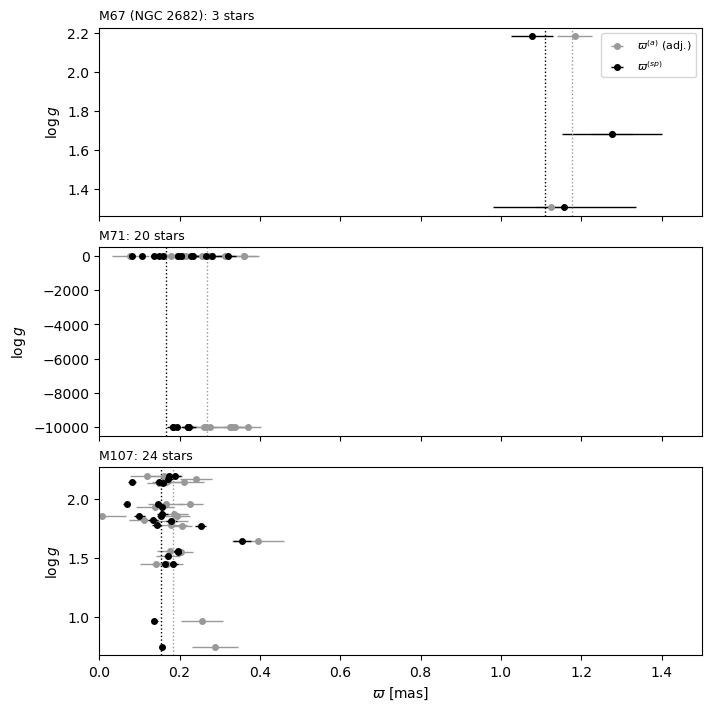

In [7]:
clusters = {'M67 (NGC 2682)': (132.846, 11.814, 0.5, 1.13),
            'M71':            (298.444, 18.779, 0.3, 0.20),
            'M107':           (248.133, -13.054, 0.3, 0.15)}   # ra, dec, radius_deg, plx_lit
fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True, constrained_layout=True)
for ax, (name, (ra, dec, rad, plx_lit)) in zip(axes, clusters.items()):
    cosd = np.cos(np.radians(dec))
    sep = np.hypot((M.ra - ra) * cosd, M.dec - dec)
    mem = (sep < rad) & ((M.plx + HOGG_OFFSET - plx_lit).abs() < 0.25)
    d = M[mem]
    ax.errorbar(d.plx + HOGG_OFFSET, d.logg, xerr=d.e_plx, fmt='o', ms=4,
                color='0.6', lw=1, label='$\\varpi^{(a)}$ (adj.)')
    ax.errorbar(d.spec_parallax, d.logg, xerr=d.spec_parallax_err, fmt='o', ms=4,
                color='k', lw=1, label='$\\varpi^{(sp)}$')
    for vals, errs, col in [(d.plx + HOGG_OFFSET, d.e_plx, '0.6'),
                            (d.spec_parallax, d.spec_parallax_err, 'k')]:
        w = 1.0/np.asarray(errs)**2
        if w.sum() > 0:
            ax.axvline(np.average(vals, weights=w), color=col, ls=':', lw=1)
    ax.set_ylabel('$\\log g$'); ax.set_title(f'{name}: {mem.sum()} stars', loc='left', fontsize=9)
axes[0].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('$\\varpi$ [mas]'); axes[-1].set_xlim(0, 1.5)
plt.show()

## 7. Retraining with our pipeline (requires the spectra)

This is the actual end-to-end code verification: refit the linear model on the original DR14 features and compare our $\varpi^{(sp)}$ star-by-star with the paper's. Build the spectra parquet first (resumable; ~10 GB traffic, ~3–5 GB on disk):

```bash
python assemble_hogg18.py --stage spectra   # download + normalize 44784 aspcapStar files
python assemble_hogg18.py --stage concat    # -> data/hogg18/hogg18_spectra.parquet
python assemble_hogg18.py --stage verify
```

then fit (band columns match the `dr17` registry entry; no pixel masks — DR14 is APO-only):

```bash
python run_full_gadi.py --dataset dr17 \
    --parquet data/hogg18/hogg18_spectra.parquet \
    --allstar data/hogg18/hogg18_allstar.fits
```

**Two deliberate differences to keep in mind** (both visible, neither hidden):
1. `prepare_sample` selects training stars with `snr > 100 & flags == 0` and its own A/B split — the paper instead uses eqs. 8–10 and their published split. Both artifacts carry `hogg_training_set` / `hogg_sample`, so the paper-exact selection can be swapped in.
2. The `zeropoint` column is set to −0.048 so `plx_corr = plx - zeropoint` equals the paper's $\varpi + 0.048$ mas.

With the paper split and L1→(our ridge+GN) differences, expect agreement in the *headline scatter* (≤8–9% on the probe) and tight star-by-star correlation, not bit-identical coefficients.

In [8]:
SPEC = '../data/hogg18/hogg18_spectra.parquet'
REFIT = '../data/hogg18/refit_predictions.npz'   # save {'sdss_id', 'plx_sp'} from the refit here
if not os.path.exists(SPEC):
    print('spectra parquet not built yet -> run the assemble stages above first')
elif not os.path.exists(REFIT):
    print('spectra ready; run the fit, save predictions to', REFIT)
else:
    r = np.load(REFIT, allow_pickle=True)
    ours = pd.DataFrame({'sdss_id': r['sdss_id'].astype(str), 'plx_ours': r['plx_sp']})
    cmp_ = M.merge(ours, on='sdss_id')
    lnr = np.log(cmp_.plx_ours / cmp_.spec_parallax)
    print(f'{len(cmp_)} stars matched')
    print(f'star-by-star: median ln-ratio {np.nanmedian(lnr):+.4f}, '
          f'robust scatter {100*robust_scatter(lnr):.2f}%')
    fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
    ax.scatter(cmp_.spec_parallax, cmp_.plx_ours, s=2, alpha=0.4, rasterized=True)
    ax.plot([0, 2], [0, 2], ':', color='0.6'); ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    ax.set_xlabel('Hogg+18 $\\varpi^{(sp)}$ [mas]'); ax.set_ylabel('our refit $\\varpi^{(sp)}$ [mas]')
    plt.show()

spectra parquet not built yet -> run the assemble stages above first
